<img style="float: middle;" src="../images/logo.png">

# Module 004 &mdash; Deep Learning 03

# A Transformer for gene expression data

In notebooks `01` and `02` you built **autoencoders** and **convolutional networks**.
This notebook introduces the architecture behind modern foundation models such as
**[scGPT](https://www.nature.com/articles/s41592-024-02201-0)** and
**[Geneformer](https://www.nature.com/articles/s41586-023-06139-9)**: the **Transformer**.

The key idea is a change of perspective:

> **A spot is a "sentence", and the genes it expresses are the "words" (tokens).**

A Transformer reads this sentence with **self-attention**, learning *which genes
should pay attention to which other genes* in order to describe a spot. We will:

1. Turn each Visium spot into a sequence of **gene tokens**.
2. Build a small Transformer encoder **from scratch** in PyTorch.
3. Train it to classify spots into **spatial domains** and inspect the **attention**.
4. (Bonus) Pre-train it **without labels** using *masked-gene modelling* &mdash; a
   miniature scGPT/Geneformer &mdash; and show the learned representation captures biology.

The data is the **10x Visium human skin** sample (`Visium_Skin_A2`).

## 0. Setup

In [1]:
import warnings, json
from pathlib import Path
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sc.settings.verbosity = 0

# Reproducibility + keep CPU usage modest on a shared teaching server
SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(4)
device = "cpu"
print("torch", torch.__version__, "| device:", device)

# ---> Point this at your copy of the Visium sample <---
DATA_DIR = Path("/QRISdata/Q1851/Xiao/winter_school_data_2025/Visium_Skin_A2/outs")

/home/uqxtan9/micromamba/envs/FSTimage/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


torch 2.9.1+cu128 | device: cpu


## 1. Load and preprocess the Visium data

Standard scanpy preprocessing: drop empty genes/spots, normalise each spot to the
same total count, and `log1p` transform. We keep the raw counts in a layer.

In [2]:
adata = sc.read_10x_h5(DATA_DIR / "filtered_feature_bc_matrix.h5")
adata.var_names_make_unique()
sc.pp.filter_genes(adata, min_cells=10)
sc.pp.filter_cells(adata, min_genes=200)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# attach spot pixel coordinates (handy for spatial plots later)
import pandas as pd
pos = pd.read_csv(DATA_DIR / "spatial/tissue_positions.csv").set_index("barcode")
pos = pos.loc[adata.obs_names]
adata.obsm["spatial"] = pos[["pxl_col_in_fullres", "pxl_row_in_fullres"]].values.astype(float)
print(adata)

AnnData object with n_obs × n_vars = 2302 × 15339
    obs: 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'log1p'
    obsm: 'spatial'
    layers: 'counts'


### 1.1 Define spatial domains (the labels we will predict)

We have no pathologist annotations, so we derive **spatial domains** the usual way:
PCA &rarr; neighbourhood graph &rarr; **Leiden** clustering. These clusters become the
target classes for the supervised part of this notebook.

In [3]:
dom = adata.copy()
sc.pp.highly_variable_genes(dom, n_top_genes=2000)
dom = dom[:, dom.var.highly_variable].copy()
sc.pp.scale(dom, max_value=10)
sc.tl.pca(dom, n_comps=30)
sc.pp.neighbors(dom, n_neighbors=15, n_pcs=30)
try:
    sc.tl.leiden(dom, resolution=0.5, key_added="domain",
                 flavor="igraph", n_iterations=2, directed=False)
except TypeError:                       # older scanpy
    sc.tl.leiden(dom, resolution=0.5, key_added="domain")

adata.obs["domain"] = dom.obs["domain"].values
labels = adata.obs["domain"].astype("category")
y = labels.cat.codes.values.astype(np.int64)
n_classes = len(labels.cat.categories)
print(f"{n_classes} spatial domains; spot counts per domain:")
print(np.bincount(y))

2026-06-25 22:37:31.526537: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-25 22:37:31.699781: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-06-25 22:37:34.953260: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


10 spatial domains; spot counts per domain:
[787 222 283 265 165 203 203  54 101  19]


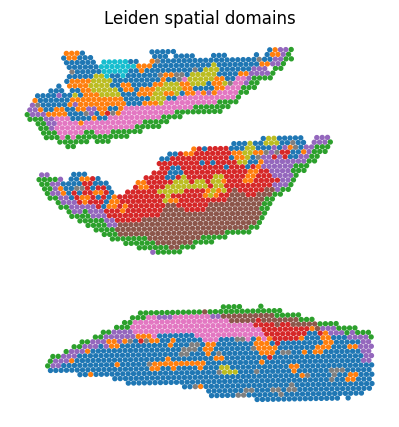

In [4]:
# Visualise the domains in tissue space
xy = adata.obsm["spatial"]
plt.figure(figsize=(5, 5))
plt.scatter(xy[:, 0], -xy[:, 1], c=y, cmap="tab10", s=8)
plt.gca().set_aspect("equal"); plt.axis("off")
plt.title("Leiden spatial domains"); plt.show()

## 2. Tokenise the gene expression

A Transformer consumes a **sequence of tokens**. We build that sequence per spot:

* **Vocabulary** = the 256 most highly-variable genes. Each gene has an integer id.
* For each spot we keep its **top-K expressed** vocabulary genes (here `K = 64`).
* Every token carries **two** pieces of information, each turned into a learnable vector
  (embedding) and **added** together:
  * *which gene* it is (`gene id embedding`), and
  * *how strongly* it is expressed, discretised into bins (`expression-bin embedding`).
* We prepend a special **`[CLS]`** token. After self-attention, the vector at the
  `[CLS]` position becomes the **summary of the whole spot** that we classify from.

Special tokens: `PAD` (padding for spots with <K genes), `CLS` (summary), `MASK` (Part 6).

In [5]:
sc.pp.highly_variable_genes(adata, n_top_genes=256)
hvg = adata.var.highly_variable.values
genes = adata.var_names[hvg].tolist()
X = adata[:, hvg].X
X = np.asarray(X.todense()) if hasattr(X, "todense") else np.asarray(X)

PAD, CLS, MASK = 0, 1, 2          # special token ids
N_SPECIAL = 3
vocab_size = len(genes) + N_SPECIAL
K = 64                            # gene tokens kept per spot
N_BINS = 10                       # expression bins 1..10 (0 = CLS/PAD/MASK)
seq_len = 1 + K
print("vocabulary:", len(genes), "genes | sequence length:", seq_len)

vocabulary: 256 genes | sequence length: 65


In [6]:
# global bin edges from the pooled non-zero expression values (deciles)
nz = X[X > 0]
edges = np.quantile(nz, np.linspace(0, 1, N_BINS + 1)[1:-1])
to_bin = lambda v: np.digitize(v, edges) + 1     # -> 1..N_BINS

N = X.shape[0]
gene_ids = np.full((N, seq_len), PAD, dtype=np.int64)
bins = np.zeros((N, seq_len), dtype=np.int64)
gene_ids[:, 0] = CLS
for i in range(N):
    row = X[i]
    nzidx = np.where(row > 0)[0]
    top = nzidx[np.argsort(row[nzidx])[::-1][:K]] if len(nzidx) > K else nzidx
    top = np.sort(top)
    L = len(top)
    gene_ids[i, 1:1 + L] = top + N_SPECIAL
    bins[i, 1:1 + L] = to_bin(row[top])
pad_mask = gene_ids == PAD        # True where padded -> ignored by attention
print("avg real gene tokens per spot:", round((~pad_mask[:, 1:]).sum(1).mean(), 1))

avg real gene tokens per spot: 40.5


In [7]:
# Peek at the token sequence for one spot
i = 0
toks = [("[CLS]", "-")] + [
    (genes[g - N_SPECIAL], int(b)) for g, b in zip(gene_ids[i, 1:], bins[i, 1:]) if g > MASK
]
print(f"Spot {adata.obs_names[i]} (domain {labels.iloc[i]}) -> {len(toks)} tokens")
print("(gene, expression-bin) for the first 12 tokens:")
for t in toks[:12]:
    print("  ", t)

Spot AACACGTGCATCGCAC-1 (domain 0) -> 18 tokens
(gene, expression-bin) for the first 12 tokens:
   ('[CLS]', '-')
   ('FMOD', 9)
   ('ASPRV1', 9)
   ('AOX1', 9)
   ('GATA2', 10)
   ('ADH1B', 10)
   ('TWIST1', 9)
   ('FAM180A', 9)
   ('SFRP1', 9)
   ('MS4A2', 10)
   ('PDGFD', 9)
   ('CLMP', 9)


## 3. Build the Transformer encoder (from scratch)

A Transformer **block** is just two sub-layers wrapped with residual connections and
layer-norm:

1. **Multi-head self-attention** &mdash; every token looks at every other token and
   produces a weighted average of their values; the weights are the *attention*.
2. A small **feed-forward network** applied to each token.

We use PyTorch's `nn.MultiheadAttention` as the attention primitive but assemble the
block ourselves, so the data flow is fully visible (and we can read out the attention).

In [8]:
class TransformerBlock(nn.Module):
    """Pre-built attention primitive, hand-wired block (post-norm)."""
    def __init__(self, d_model, nhead, dim_ff, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, dim_ff), nn.GELU(),
                                nn.Dropout(dropout), nn.Linear(dim_ff, d_model))
        self.drop = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None, need_weights=False):
        a, w = self.attn(x, x, x, key_padding_mask=key_padding_mask,
                         need_weights=need_weights, average_attn_weights=True)
        x = self.norm1(x + self.drop(a))     # residual + norm
        x = self.norm2(x + self.ff(x))       # residual + norm
        return x, w


class GeneTransformer(nn.Module):
    def __init__(self, vocab, n_bins, d_model=64, nhead=4, depth=2, dim_ff=128, n_classes=8):
        super().__init__()
        self.gene_emb = nn.Embedding(vocab, d_model, padding_idx=PAD)
        self.bin_emb = nn.Embedding(n_bins + 1, d_model, padding_idx=0)
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, nhead, dim_ff) for _ in range(depth)])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, n_classes)

    def encode(self, g, b, mask, need_weights=False):
        x = self.gene_emb(g) + self.bin_emb(b)        # token = gene id + expression bin
        attns = []
        for blk in self.blocks:
            x, w = blk(x, key_padding_mask=mask, need_weights=need_weights)
            attns.append(w)
        return x, attns

    def forward(self, g, b, mask, need_weights=False):
        x, attns = self.encode(g, b, mask, need_weights)
        return self.head(self.norm(x[:, 0])), attns   # classify from [CLS]

## 4. Train the spatial-domain classifier

We split spots into train/validation sets (stratified by domain) and train with
cross-entropy. The model is tiny (&approx;85k parameters) so this runs in a couple of
minutes on CPU.

In [9]:
idx = np.arange(N)
tr, te = train_test_split(idx, test_size=0.25, random_state=SEED, stratify=y)

def get_batch(ids):
    return (torch.tensor(gene_ids[ids]), torch.tensor(bins[ids]),
            torch.tensor(pad_mask[ids]), torch.tensor(y[ids]))

model = GeneTransformer(vocab_size, N_BINS, n_classes=n_classes).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
print("trainable parameters:", sum(p.numel() for p in model.parameters()))

EPOCHS, BS = 25, 64
hist = {"loss": [], "val_acc": []}
for ep in range(EPOCHS):
    model.train(); perm = np.random.permutation(tr); ep_loss = 0.0
    for s in range(0, len(perm), BS):
        g, b, m, t = get_batch(perm[s:s + BS])
        opt.zero_grad()
        out, _ = model(g, b, m)
        loss = loss_fn(out, t)
        loss.backward(); opt.step()
        ep_loss += loss.item() * len(t)
    model.eval()
    with torch.no_grad():
        g, b, m, t = get_batch(te)
        val_acc = (model(g, b, m)[0].argmax(1) == t).float().mean().item()
    hist["loss"].append(ep_loss / len(tr)); hist["val_acc"].append(val_acc)
    if (ep + 1) % 5 == 0 or ep == 0:
        print(f"epoch {ep+1:2d}  train_loss {hist['loss'][-1]:.3f}  val_acc {val_acc:.3f}")

trainable parameters: 85002


epoch  1  train_loss 1.596  val_acc 0.615


epoch  5  train_loss 0.556  val_acc 0.780


epoch 10  train_loss 0.264  val_acc 0.816


epoch 15  train_loss 0.155  val_acc 0.819


epoch 20  train_loss 0.069  val_acc 0.825


epoch 25  train_loss 0.067  val_acc 0.812


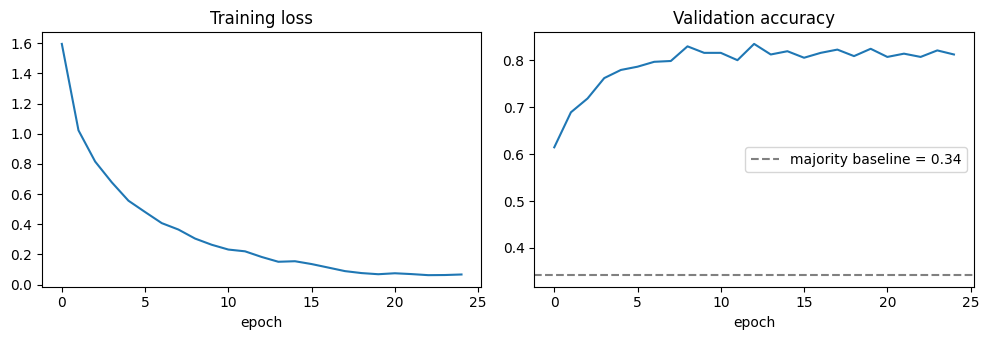

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(hist["loss"]); ax[0].set_title("Training loss"); ax[0].set_xlabel("epoch")
ax[1].plot(hist["val_acc"]); ax[1].set_title("Validation accuracy"); ax[1].set_xlabel("epoch")
baseline = np.bincount(y[te]).max() / len(te)
ax[1].axhline(baseline, ls="--", c="grey", label=f"majority baseline = {baseline:.2f}")
ax[1].legend(); plt.tight_layout(); plt.show()

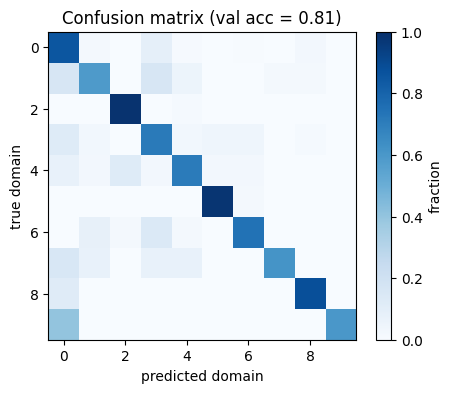

In [11]:
from sklearn.metrics import confusion_matrix
model.eval()
with torch.no_grad():
    g, b, m, t = get_batch(te)
    pred = model(g, b, m)[0].argmax(1).numpy()
cm = confusion_matrix(y[te], pred, normalize="true")
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(label="fraction"); plt.xlabel("predicted domain"); plt.ylabel("true domain")
plt.title(f"Confusion matrix (val acc = {(pred == y[te]).mean():.2f})"); plt.show()

## 5. What is the model attending to?

The attention weights are interpretable. For each spot we read the attention from the
`[CLS]` token to every gene token in the **last** block. Averaging these weights across
all spots of a domain tells us **which genes the model relies on** to recognise that
domain &mdash; a built-in, biology-friendly explanation.

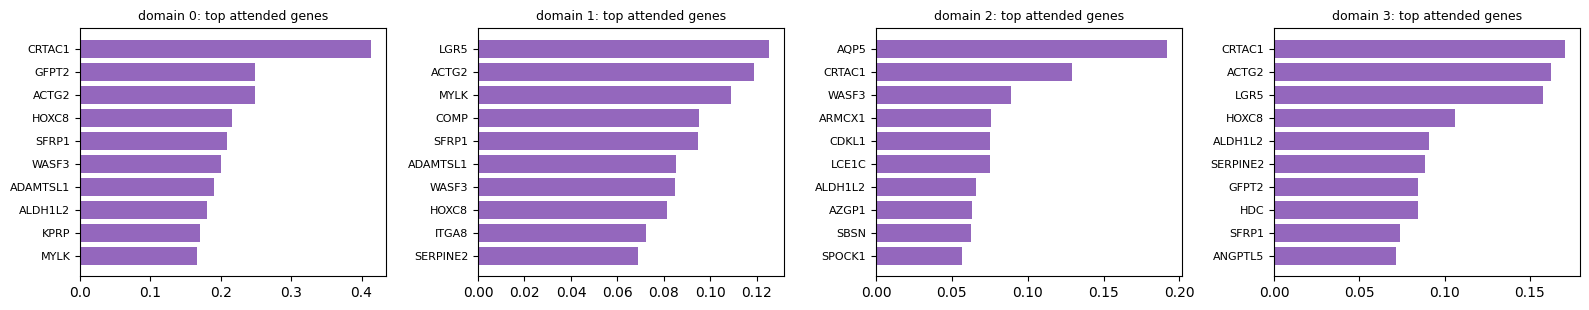

In [12]:
model.eval()
with torch.no_grad():
    g, b, m, t = get_batch(te)
    _, attns = model(g, b, m, need_weights=True)
cls_attn = attns[-1][:, 0, 1:].numpy()     # [n_val, K]  CLS -> gene tokens
gids_val = gene_ids[te]

import collections
def top_genes_for_domain(d, topn=10, min_count=5):
    sel = np.where(y[te] == d)[0]
    tot = collections.defaultdict(float); cnt = collections.defaultdict(int)
    for i in sel:
        for j in range(1, seq_len):
            gid = gids_val[i, j]
            if gid > MASK:
                tot[gid] += cls_attn[i, j - 1]; cnt[gid] += 1
    sc_ = {gid: tot[gid] / cnt[gid] for gid in tot if cnt[gid] >= min_count}
    top = sorted(sc_, key=sc_.get, reverse=True)[:topn]
    return [genes[t_ - N_SPECIAL] for t_ in top], [sc_[t_] for t_ in top]

ndom = min(4, n_classes)
fig, axes = plt.subplots(1, ndom, figsize=(4 * ndom, 3.2))
for d, ax in enumerate(axes):
    gnames, gscore = top_genes_for_domain(d)
    ax.barh(range(len(gnames))[::-1], gscore, color="tab:purple")
    ax.set_yticks(range(len(gnames))[::-1]); ax.set_yticklabels(gnames, fontsize=8)
    ax.set_title(f"domain {d}: top attended genes", fontsize=9)
plt.tight_layout(); plt.show()

## 6. Bonus &mdash; self-supervised *masked-gene modelling*

So far we used labels. Foundation models like **scGPT/Geneformer** are first pre-trained
**without any labels** by *masked modelling*: hide some gene tokens and ask the model to
predict them from the surrounding context. The encoder is forced to learn the
**co-expression structure** of genes.

Here we hide 15% of the gene tokens and predict their **expression bin**. Afterwards we
**freeze** the encoder, take a spot embedding (mean over its tokens), and check &mdash; with
a simple k-nearest-neighbour probe &mdash; how much biology that label-free representation
captured.

In [13]:
class GeneMLM(nn.Module):
    def __init__(self, vocab, n_bins, d_model=64, nhead=4, depth=2, dim_ff=128):
        super().__init__()
        self.gene_emb = nn.Embedding(vocab, d_model, padding_idx=PAD)
        self.bin_emb = nn.Embedding(n_bins + 1, d_model, padding_idx=0)
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, nhead, dim_ff) for _ in range(depth)])
        self.norm = nn.LayerNorm(d_model)
        self.bin_head = nn.Linear(d_model, n_bins + 1)   # predict expression bin

    def encode(self, g, b, mask):
        x = self.gene_emb(g) + self.bin_emb(b)
        for blk in self.blocks:
            x, _ = blk(x, key_padding_mask=mask)
        return x

mlm = GeneMLM(vocab_size, N_BINS)
opt2 = torch.optim.Adam(mlm.parameters(), lr=1e-3)
MASK_P = 0.15
for ep in range(30):
    mlm.train(); perm = np.random.permutation(tr)
    for s in range(0, len(perm), BS):
        ids = perm[s:s + BS]
        g = torch.tensor(gene_ids[ids]); b = torch.tensor(bins[ids]); m = torch.tensor(pad_mask[ids])
        real = (~m) & (torch.arange(seq_len) > 0)            # maskable = real gene tokens
        mp = (torch.rand_like(g, dtype=torch.float) < MASK_P) & real
        if mp.sum() == 0:
            continue
        tgt = b.clone()
        g_in = g.clone(); g_in[mp] = MASK                    # hide gene identity
        b_in = b.clone(); b_in[mp] = 0                       # hide expression
        logits = mlm.bin_head(mlm.norm(mlm.encode(g_in, b_in, m)))
        loss = loss_fn(logits[mp], tgt[mp])                  # predict only masked tokens
        opt2.zero_grad(); loss.backward(); opt2.step()
    if (ep + 1) % 10 == 0:
        print(f"[masked-gene pretraining] epoch {ep+1}  loss {loss.item():.3f}")

[masked-gene pretraining] epoch 10  loss 1.276


[masked-gene pretraining] epoch 20  loss 1.331


[masked-gene pretraining] epoch 30  loss 1.316


kNN on FROZEN self-supervised embedding: 0.670  (majority baseline 0.342)
-> masked-gene pretraining learned domain structure WITHOUT ever seeing labels.


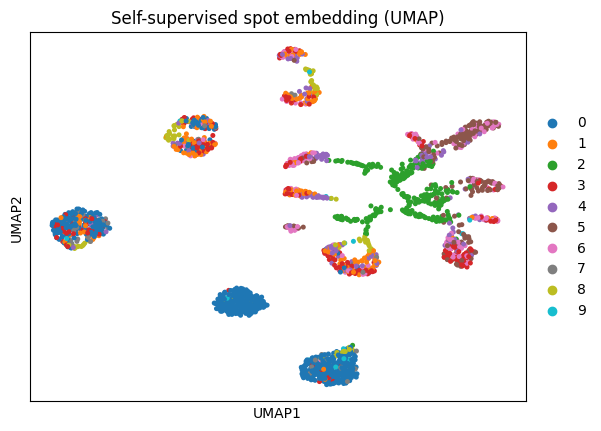

In [14]:
# Freeze encoder -> spot embedding (mean over real tokens) -> kNN probe + UMAP
from sklearn.neighbors import KNeighborsClassifier
with torch.no_grad():
    tok = mlm.encode(torch.tensor(gene_ids), torch.tensor(bins), torch.tensor(pad_mask))
    w = (~torch.tensor(pad_mask)).float().unsqueeze(-1); w[:, 0] = 0      # exclude CLS
    emb = ((tok * w).sum(1) / w.sum(1).clamp(min=1)).numpy()

knn = KNeighborsClassifier(15).fit(emb[tr], y[tr])
probe_acc = (knn.predict(emb[te]) == y[te]).mean()
print(f"kNN on FROZEN self-supervised embedding: {probe_acc:.3f}  "
      f"(majority baseline {baseline:.3f})")
print("-> masked-gene pretraining learned domain structure WITHOUT ever seeing labels.")

emb_ad = sc.AnnData(emb); emb_ad.obs["domain"] = labels.values
sc.pp.neighbors(emb_ad, use_rep="X"); sc.tl.umap(emb_ad)
sc.pl.umap(emb_ad, color="domain", title="Self-supervised spot embedding (UMAP)")

## 7. Questions & exercises

<span style="color:blue">**Q1.**</span> Why do we add a single `[CLS]` token and classify
from it, instead of averaging all gene tokens? What would change if you mean-pooled instead?

<span style="color:blue">**Q2.**</span> Increase `depth` (number of blocks) and `nhead`
(attention heads). Does validation accuracy improve? At what cost?

<span style="color:blue">**Q3.**</span> Change `K` (genes kept per spot) to 16 and to 128.
How does the amount of context affect accuracy and runtime?

<span style="color:blue">**Q4.**</span> In Part 6, raise the masking ratio `MASK_P` to 0.4.
Does the frozen-embedding probe get better or worse? Why might too much masking hurt?

<span style="color:purple">**Going further.**</span> The environment also ships
`transformers`, `timm` and `einops`. As an extension, try loading a pretrained
single-cell Transformer, or re-implement the block above with `einops.rearrange`.